In [90]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

In [91]:
df = pd.read_csv("cleaned_data/egx30.csv")
df['date'] = pd.to_datetime(df['date'])
df = df.set_index('date').sort_index()

In [92]:
df.shape

(2754, 6)

In [93]:
df.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 2754 entries, 2015-01-04 to 2026-04-30
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   price       2754 non-null   float64
 1   open        2754 non-null   float64
 2   high        2754 non-null   float64
 3   low         2754 non-null   float64
 4   vol         2743 non-null   float64
 5   change_pct  2754 non-null   float64
dtypes: float64(6)
memory usage: 150.6 KB


In [94]:
df.head()

,price,open,high,low,vol,change_pct
date,,,,,,
2015-01-04,8942.65,8926.26,8942.65,8880.21,62.86,0.18
2015-01-05,9011.07,8941.72,9033.07,8931.80,86.76,0.77
2015-01-06,8798.94,8971.93,8971.93,8754.87,105.19,-2.35
2015-01-08,8946.34,8819.61,8954.29,8819.61,82.04,1.68
2015-01-11,8909.75,8945.69,8957.59,8909.75,45.71,-0.41


In [95]:
df.tail()

,price,open,high,low,vol,change_pct
date,,,,,,
2026-04-26,52421.14,52375.39,52632.40,52327.40,699.41,0.09
2026-04-27,52719.12,52421.14,52865.76,52353.93,341.83,0.57
2026-04-28,52230.61,52719.12,52896.87,52213.64,402.73,-0.93
2026-04-29,52383.13,52230.61,52431.85,52096.15,420.47,0.29
2026-04-30,51760.97,52383.13,52538.84,51748.64,637.54,-1.19


In [96]:
#print null count
print(df.isnull().sum())

price          0
open           0
high           0
low            0
vol           11
change_pct     0
dtype: int64


In [97]:
#fill missing values in volume colummn with mean
df['vol'] = df['vol'].fillna(df['vol'].mean())

In [98]:
#Computing daily % return 
df['return'] = df['price'].pct_change() 

In [99]:
#Adding lag features
df['return_lag1'] = df['return'].shift(1)
df['return_lag2'] = df['return'].shift(2)

In [100]:
#Adding rolling features
df['ma_20']         = df['price'].rolling(20).mean()
df['volatility_20'] = df['return'].rolling(20).std()
df['ma_5']          = df['price'].rolling(5).mean()

In [101]:
df['dist_to_ma5'] = (df['price'] / df['ma_5']) - 1
df['dist_to_ma20'] = (df['price'] / df['ma_20']) - 1

In [102]:
# 1. Calculate the Fast (12-day) and Slow (26-day) Exponential Moving Averages (EMA)
ema_12 = df['price'].ewm(span=12, adjust=False).mean()
ema_26 = df['price'].ewm(span=26, adjust=False).mean()

# 2. Calculate the raw MACD line
df['macd'] = ema_12 - ema_26

# 3. Calculate the Signal Line (9-day EMA of the MACD)
df['macd_signal'] = df['macd'].ewm(span=9, adjust=False).mean()

# 4. Calculate the MACD Histogram (The most useful feature for ML)
# This represents the distance between the MACD and its signal line
df['macd_hist'] = df['macd'] - df['macd_signal']

# What this does: A rising macd_hist means short-term momentum is accelerating upward.

In [103]:
# 1. Calculate the 20-day SMA (Middle Band) and 20-day Standard Deviation
window = 20
sma_20 = df['price'].rolling(window=window).mean()
std_20 = df['price'].rolling(window=window).std()

# 2. Calculate Upper and Lower Bands
upper_band = sma_20 + (std_20 * 2)
lower_band = sma_20 - (std_20 * 2)

# 3. Feature A: Bollinger %B (Where is price relative to the bands?)
# Value of 1.0 = price is touching upper band. Value of 0.0 = touching lower band.
df['bb_pb'] = (df['price'] - lower_band) / (upper_band - lower_band)

# 4. Feature B: Bollinger Bandwidth (How volatile is the market right now?)
# Useful for detecting "squeezes" before explosive moves.
df['bb_bandwidth'] = (upper_band - lower_band) / sma_20

In [104]:
#Adding RSI
delta = df['price'].diff()
gain  = delta.clip(lower=0).rolling(14).mean()
loss  = (-delta.clip(upper=0)).rolling(14).mean()
df['rsi'] = 100 - (100 / (1 + gain / loss))

In [105]:
threshold = 0.005

future_return = df['return'].shift(-1)

df['label'] = (future_return > threshold).astype(int)

In [106]:
#Adding rolling features adds NaN rows
df = df.dropna()

In [107]:
df.drop(columns=['price', 'ma_5', 'ma_20'], inplace=True)

In [108]:
# Note for modeling team: price, ma_5, ma_20 are in EGP price scale
# while return, rsi etc. are percentages. Please apply StandardScaler or MinMaxScaler before training.
df.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 2734 entries, 2015-02-03 to 2026-04-30
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   open           2734 non-null   float64
 1   high           2734 non-null   float64
 2   low            2734 non-null   float64
 3   vol            2734 non-null   float64
 4   change_pct     2734 non-null   float64
 5   return         2734 non-null   float64
 6   return_lag1    2734 non-null   float64
 7   return_lag2    2734 non-null   float64
 8   volatility_20  2734 non-null   float64
 9   dist_to_ma5    2734 non-null   float64
 10  dist_to_ma20   2734 non-null   float64
 11  macd           2734 non-null   float64
 12  macd_signal    2734 non-null   float64
 13  macd_hist      2734 non-null   float64
 14  bb_pb          2734 non-null   float64
 15  bb_bandwidth   2734 non-null   float64
 16  rsi            2734 non-null   float64
 17  label          2734 non-null   int64  
dtypes

In [109]:
df.head()

,open,high,low,vol,change_pct,return,return_lag1,return_lag2,volatility_20,dist_to_ma5,dist_to_ma20,macd,macd_signal,macd_hist,bb_pb,bb_bandwidth,rsi,label
date,,,,,,,,,,,,,,,,,,
2015-02-03,9835.43,9961.67,9835.43,152.66,1.26,0.012602,0.005184,-0.006435,0.012506,0.010154,0.042740,231.878160,217.738825,14.139336,0.761924,0.163179,77.883585,1
2015-02-04,9960.63,10066.11,9957.28,108.85,0.92,0.009201,0.012602,0.005184,0.012525,0.015693,0.046662,237.883633,221.767786,16.115847,0.792124,0.159732,74.752646,0
2015-02-05,10046.28,10046.28,9945.59,96.19,-0.80,-0.008013,0.009201,0.012602,0.011019,0.005068,0.032003,233.456198,224.105469,9.350730,0.726049,0.141577,68.914923,0
2015-02-08,9965.08,10041.67,9957.57,75.48,-0.08,-0.000753,-0.008013,0.009201,0.010839,0.000715,0.025853,226.728650,224.630105,2.098545,0.706429,0.125240,70.052125,0
2015-02-09,9956.03,9956.03,9883.69,93.90,-0.74,-0.007378,-0.000753,-0.008013,0.011014,-0.007746,0.013198,213.013122,222.306708,-9.293586,0.633563,0.098812,63.334081,0


In [110]:
df.tail()

,open,high,low,vol,change_pct,return,return_lag1,return_lag2,volatility_20,dist_to_ma5,dist_to_ma20,macd,macd_signal,macd_hist,bb_pb,bb_bandwidth,rsi,label
date,,,,,,,,,,,,,,,,,,
2026-04-26,52375.39,52632.40,52327.40,699.41,0.09,0.000874,0.007948,-0.000288,0.016438,0.005972,0.066035,1360.803979,977.986832,382.817147,0.814784,0.209778,81.245847,1
2026-04-27,52421.14,52865.76,52353.93,341.83,0.57,0.005684,0.000874,0.007948,0.015864,0.008186,0.065254,1399.541644,1062.297794,337.243850,0.809526,0.210820,81.068389,0
2026-04-28,52719.12,52896.87,52213.64,402.73,-0.93,-0.009266,0.005684,0.000874,0.014415,-0.002123,0.047929,1374.973016,1124.832839,250.140177,0.741898,0.198138,86.152639,0
2026-04-29,52230.61,52431.85,52096.15,420.47,0.29,0.002920,-0.009266,0.005684,0.014415,-0.000815,0.043597,1352.221720,1170.310615,181.911105,0.739250,0.182222,82.032740,0
2026-04-30,52383.13,52538.84,51748.64,637.54,-1.19,-0.011877,0.002920,-0.009266,0.013883,-0.010363,0.026061,1269.355699,1190.119632,79.236067,0.652254,0.171169,72.160911,0


In [111]:
df.drop(columns=['open', 'high', 'low', 'change_pct'], inplace=True)

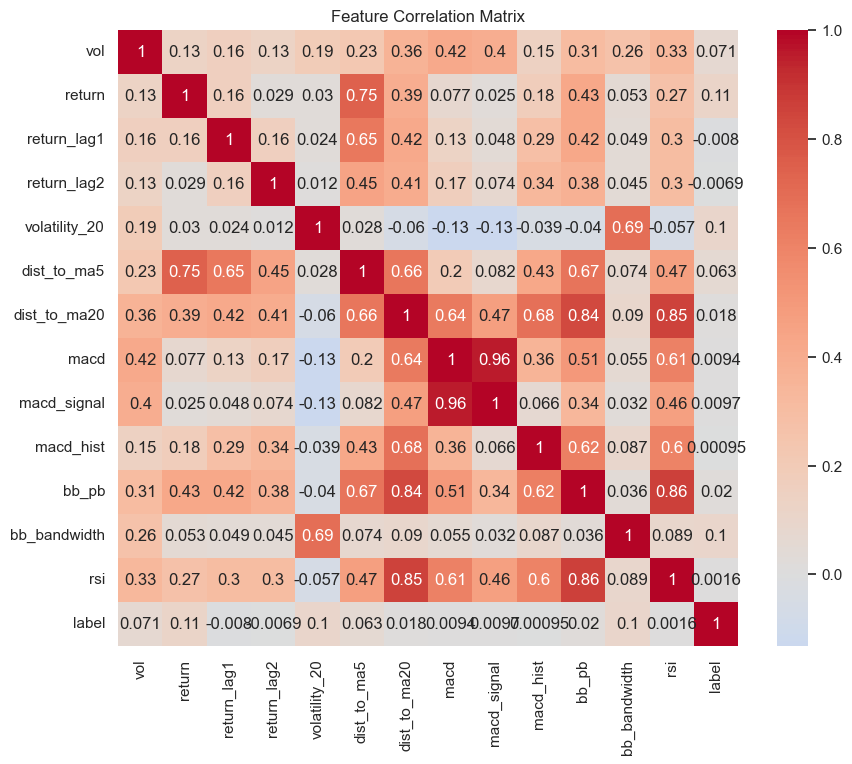

In [112]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', center=0)

plt.title('Feature Correlation Matrix')
plt.show()

In [113]:
#Dropping multicolinearity features
df.drop(columns=['dist_to_ma20', 'macd', 'macd_signal', 'volatility_20'], inplace=True)

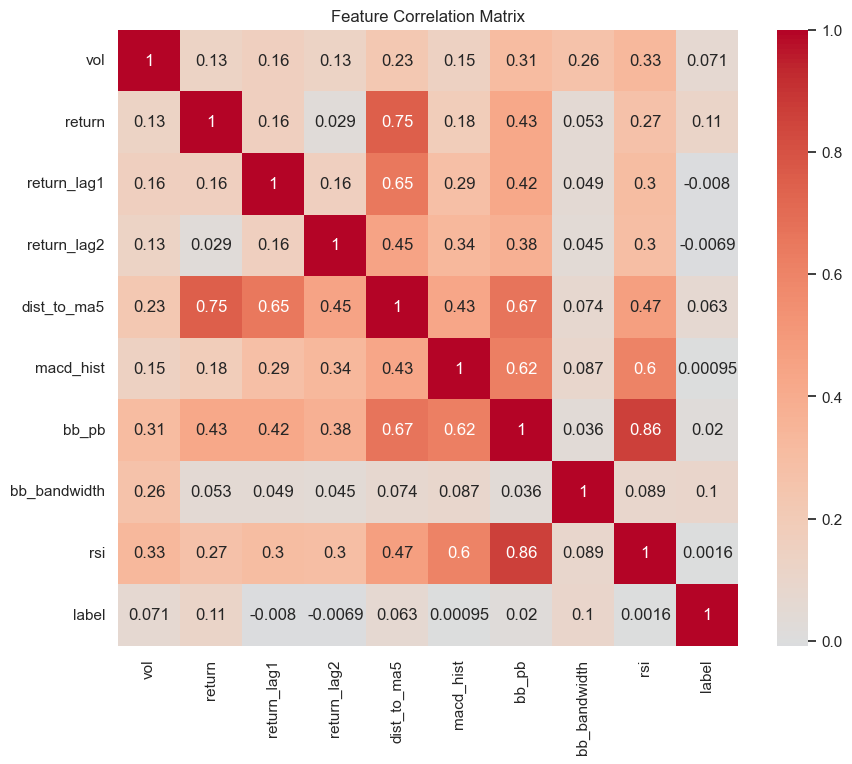

In [114]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', center=0)

plt.title('Feature Correlation Matrix')
plt.show()

In [115]:
asset_name = "EGX30 Index" 
sns.set_theme(style="darkgrid", palette="muted")

# We calculate Cumulative Return to visualize the "price" growth
cum_return = (1 + df['return']).cumprod()

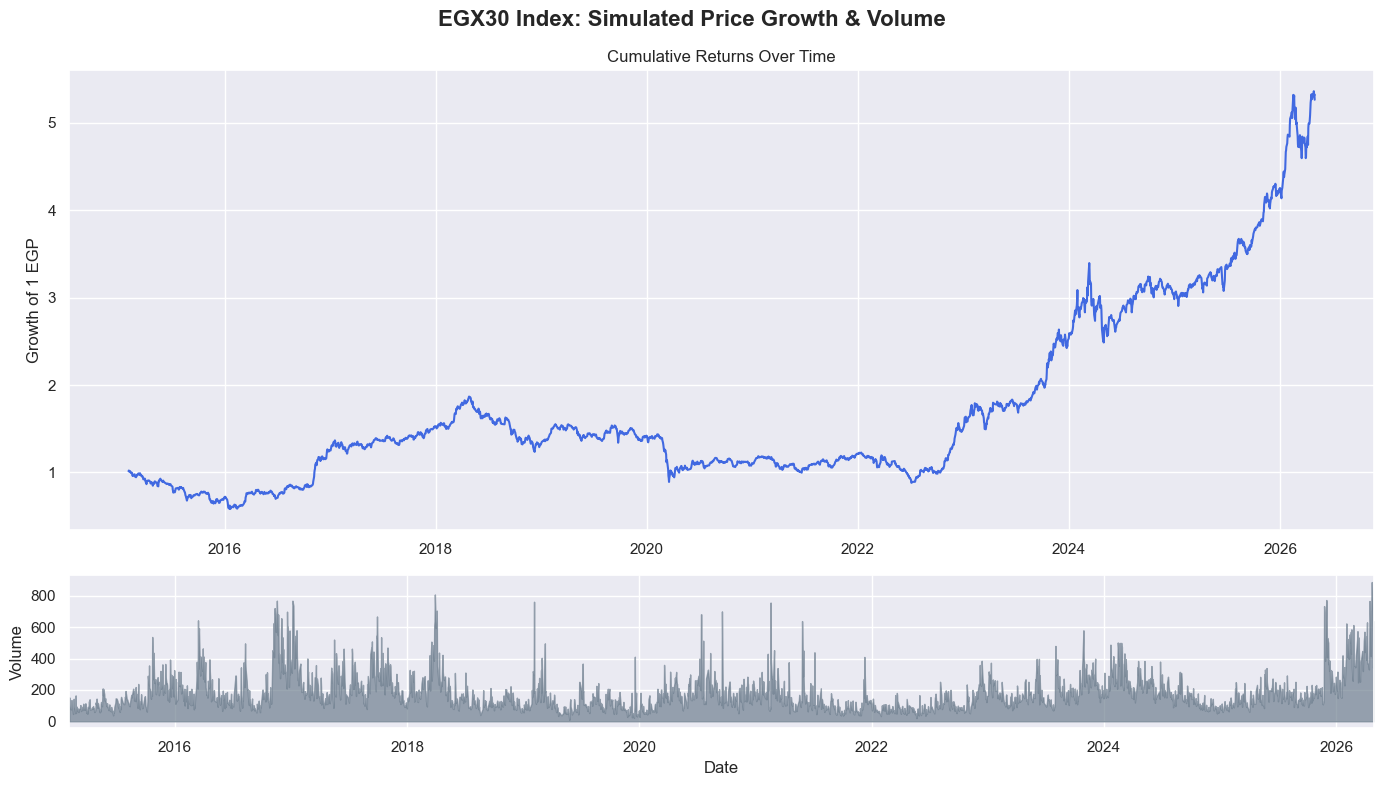

In [116]:
# ========================================================
# PLOT 1 - Macro Trend & Volume
# ========================================================
if 'vol' in df.columns:
    fig, axes = plt.subplots(2, 1, figsize=(14, 8), gridspec_kw={'height_ratios': [3, 1]})
    fig.suptitle(f"{asset_name}: Simulated Price Growth & Volume", fontsize=16, fontweight='bold')
    
    # Top Panel: Simulated Price (Cumulative Return)
    axes[0].plot(df.index, cum_return, color='royalblue', linewidth=1.5)
    axes[0].set_ylabel("Growth of 1 EGP")
    axes[0].set_title("Cumulative Returns Over Time")
    
    # Bottom Panel: Volume (FIXED: using fill_between instead of bar)
    axes[1].fill_between(df.index, df['vol'], color='slategray', alpha=0.7)
    axes[1].set_ylabel("Volume")
    axes[1].set_xlabel("Date")
    axes[1].margins(x=0) # Removes white space on the edges
    
else:
    fig, ax = plt.subplots(figsize=(14, 5))
    fig.suptitle(f"{asset_name}: Simulated Price Growth (No Volume Data)", fontsize=16, fontweight='bold')
    ax.plot(df.index, cum_return, color='royalblue', linewidth=1.5)
    ax.set_ylabel("Growth of 1 EGP")

plt.tight_layout()
plt.show()

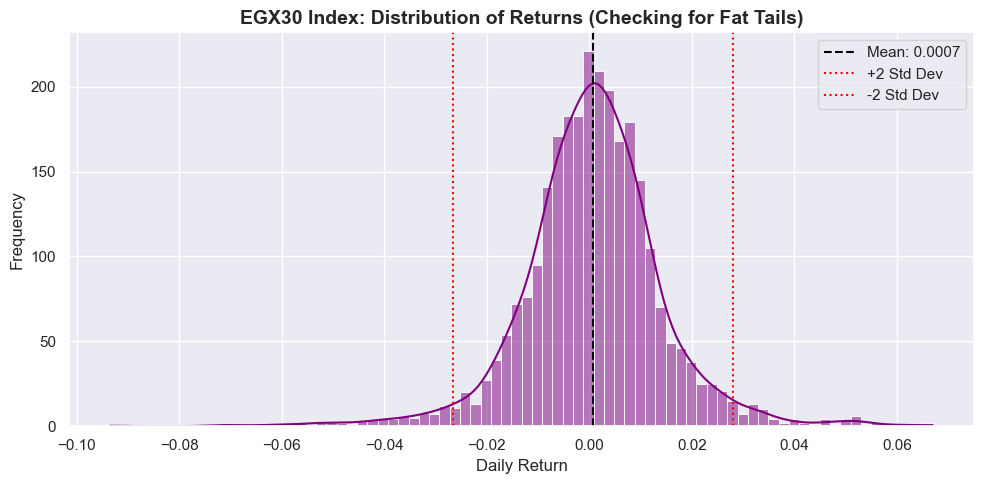

In [117]:
# ========================================================
# PLOT 2 - Distribution of Returns (Fat Tails)
# ========================================================
plt.figure(figsize=(10, 5))
sns.histplot(df['return'], kde=True, bins=80, color='purple')
plt.title(f"{asset_name}: Distribution of Returns (Checking for Fat Tails)", fontsize=14, fontweight='bold')
plt.xlabel("Daily Return")
plt.ylabel("Frequency")

# Add statistical lines
mean_ret = df['return'].mean()
std_ret = df['return'].std()
plt.axvline(mean_ret, color='black', linestyle='--', label=f'Mean: {mean_ret:.4f}')
plt.axvline(mean_ret + (2*std_ret), color='red', linestyle=':', label='+2 Std Dev')
plt.axvline(mean_ret - (2*std_ret), color='red', linestyle=':', label='-2 Std Dev')

plt.legend()
plt.tight_layout()
plt.show()

C:\Users\moata\AppData\Local\Temp\ipykernel_6012\3776502680.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df, x='label', palette=['#ff6b6b', '#1dd1a1'])


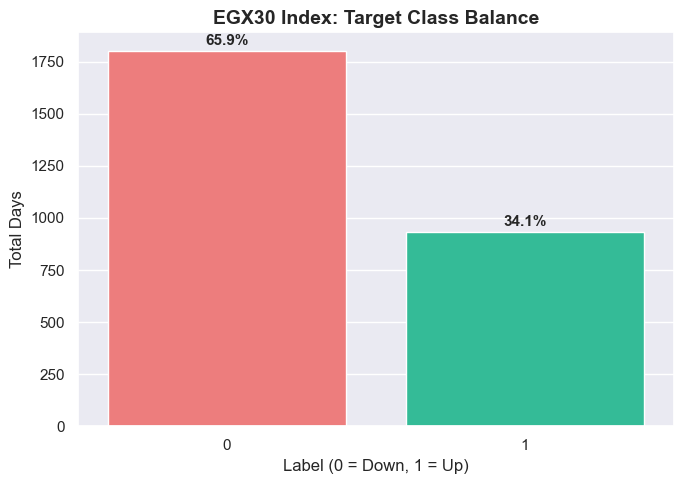

In [118]:
# ========================================================
# PLOT 3 - Target Class Balance
# ========================================================
plt.figure(figsize=(7, 5))
ax = sns.countplot(data=df, x='label', palette=['#ff6b6b', '#1dd1a1'])
plt.title(f"{asset_name}: Target Class Balance", fontsize=14, fontweight='bold')
plt.xlabel("Label (0 = Down, 1 = Up)")
plt.ylabel("Total Days")

# Calculate and add percentages to the bars
total = len(df)
for p in ax.patches:
    percentage = f'{100 * p.get_height() / total:.1f}%'
    x = p.get_x() + p.get_width() / 2
    y = p.get_height() + (total * 0.01)
    ax.annotate(percentage, (x, y), ha='center', fontweight='bold', fontsize=11)
    
plt.tight_layout()
plt.show()

C:\Users\moata\AppData\Local\Temp\ipykernel_6012\2827658916.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x='label', y=feature, ax=axes[i], palette=['#ff6b6b', '#1dd1a1'])
C:\Users\moata\AppData\Local\Temp\ipykernel_6012\2827658916.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x='label', y=feature, ax=axes[i], palette=['#ff6b6b', '#1dd1a1'])
C:\Users\moata\AppData\Local\Temp\ipykernel_6012\2827658916.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x='label', y=feature, ax=axes[i], palett

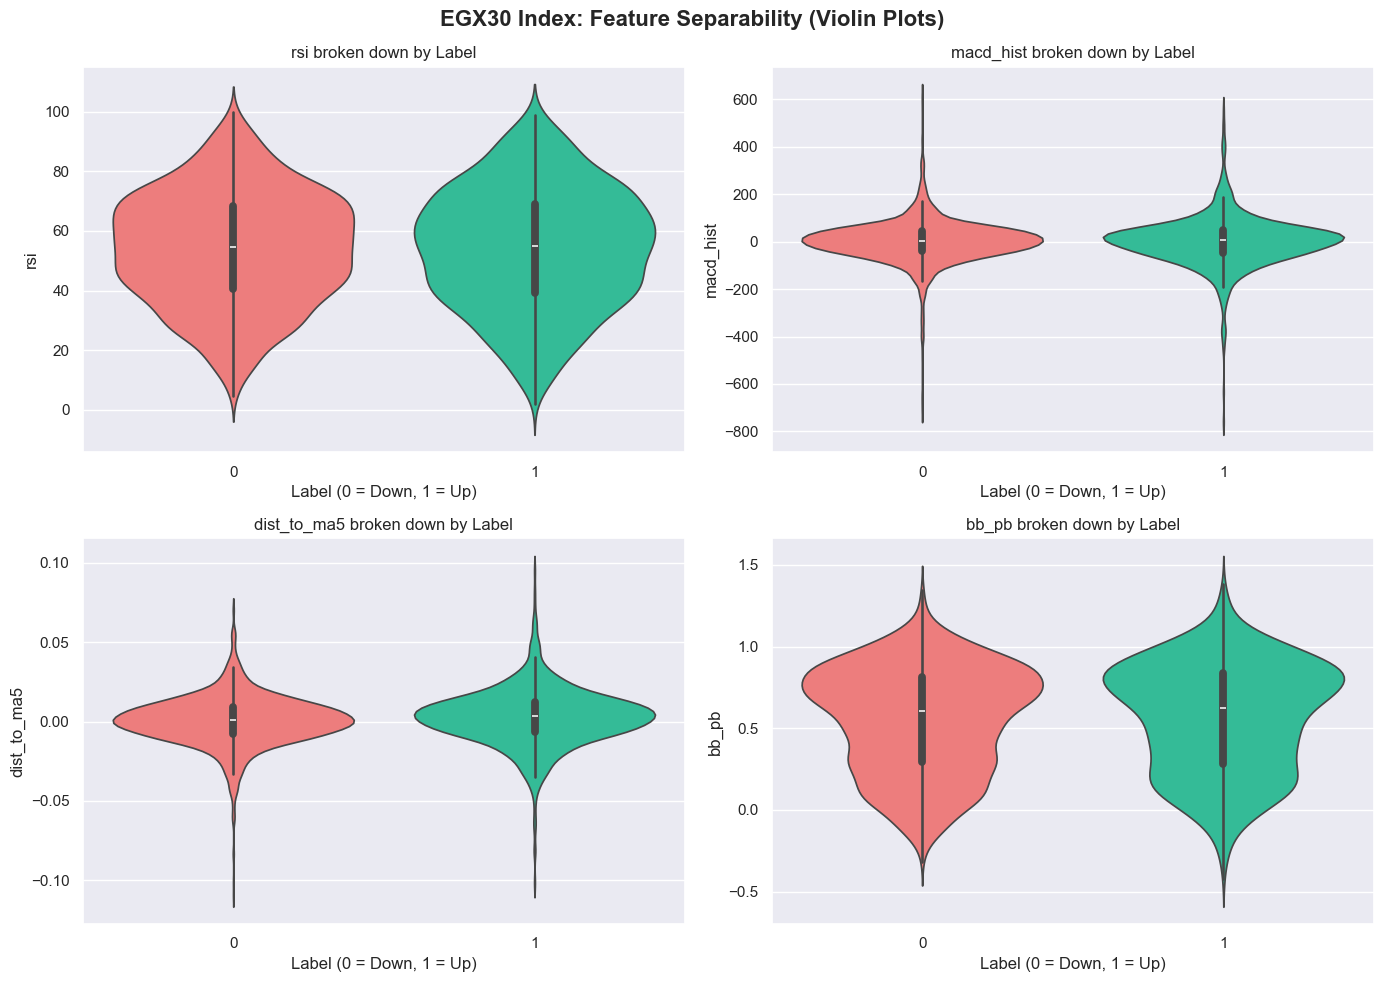

In [119]:
# ========================================================
# PLOT 4 - Feature Predictability (Violin Plots)
# ========================================================
# Selecting the 4 best ML features to plot
features = ['rsi', 'macd_hist', 'dist_to_ma5', 'bb_pb']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle(f"{asset_name}: Feature Separability (Violin Plots)", fontsize=16, fontweight='bold')
axes = axes.flatten()

for i, feature in enumerate(features):
    sns.violinplot(data=df, x='label', y=feature, ax=axes[i], palette=['#ff6b6b', '#1dd1a1'])
    axes[i].set_title(f"{feature} broken down by Label")
    axes[i].set_xlabel("Label (0 = Down, 1 = Up)")

plt.tight_layout()
plt.show()

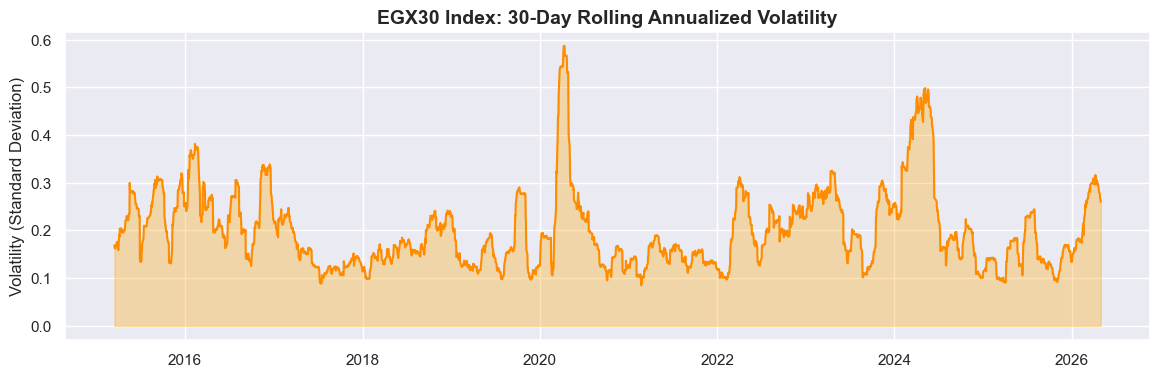

In [120]:
# CELL 7: Rolling Volatility (30-day)
df['rolling_volatility'] = df['return'].rolling(window=30).std() * np.sqrt(252) # Annualized

plt.figure(figsize=(14, 4))
plt.plot(df.index, df['rolling_volatility'], color='darkorange', linewidth=1.5)
plt.title(f"{asset_name}: 30-Day Rolling Annualized Volatility", fontsize=14, fontweight='bold')
plt.ylabel("Volatility (Standard Deviation)")
plt.fill_between(df.index, df['rolling_volatility'], alpha=0.3, color='orange')
plt.show()

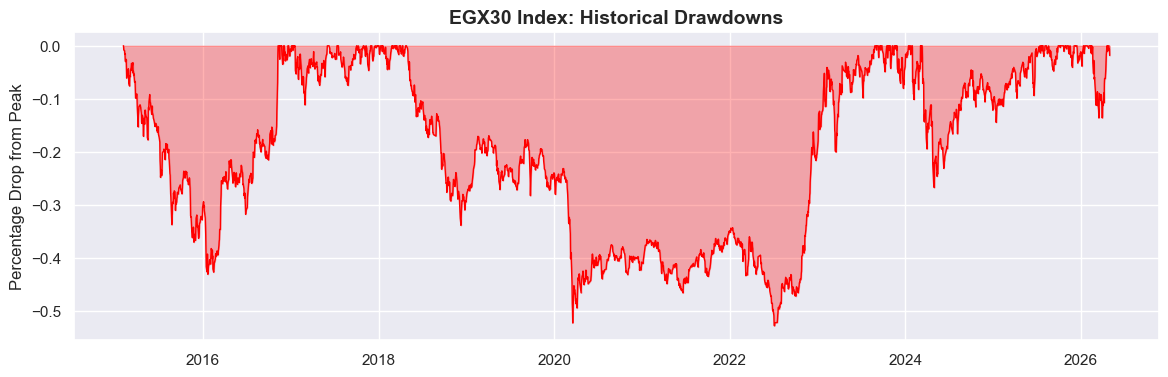

In [122]:
# CELL 8: Drawdown Chart
running_max = cum_return.cummax()
drawdown = (cum_return - running_max) / running_max

plt.figure(figsize=(14, 4))
plt.plot(df.index, drawdown, color='red', linewidth=1)
plt.fill_between(df.index, drawdown, 0, color='red', alpha=0.3)
plt.title(f"{asset_name}: Historical Drawdowns", fontsize=14, fontweight='bold')
plt.ylabel("Percentage Drop from Peak")
plt.show()

In [ ]:
df.to_csv('final_data/final_EGX30.csv')